# Milk Pooling and Blending

**Adapted, with thanks, from work by the late Jeffrey Kantor.**

This notebook is adapted from notebook 5.1, *Milk pooling and blending*, in the companion notebook collection for M. Postek, A. Zocca, J. Gromicho and J. Kantor, [*Hands-On Mathematical Optimization with Python*](https://mobook.github.io/MO-book/) (Cambridge University Press, 2025). Jeff Kantor was a colleague in this department; the example, the data and the framing of the three options are his.

The underlying problem is the canonical **pooling** benchmark of C. A. Haverly, "Studies of the behavior of recursion for the pooling problem," *ACM SIGMAP Bulletin* **25** (1978), 19--28.

```
MIT License

Copyright (c) 2022 Jeffrey Kantor

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE
SOFTWARE.
```

**What is different here.** The models are rewritten with named `pyo.Set` and `pyo.Param` components so that the Pyomo code reads as the set-notation model in the lecture notes, the solver is `ipopt` throughout rather than `appsi_highs`, and the convex (McCormick) relaxation is left to the global optimization lecture. Two typographical errors in the source notebook's mathematics are corrected: its blending constraints are printed with the summation running over the cross product $L \times C$ inside a constraint that is already quantified for all $c \in C$, and the sum must run over $l \in L$ alone. Its Pyomo code is correct as written.


In [1]:
# This code cell installs packages on Colab

import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyomo.environ as pyo

## Problem description

A bulk distributor supplies custom milk blends to several customers. Each customer specifies a minimum fat content, pays a fixed price per unit, and will buy no more than a stated maximum. The distributor sources raw milk from local farms, each producing milk of known fat content at a known cost.

The distributor has found cheaper raw milk at some **remote** farms. But it owns only one truck with a single tank for the remote route, so milk from the remote farms must be mixed in that tank before transport. That creates a **pool** of uniform composition, which is then blended with local milk to meet each customer's requirement.

Three options:

1. **Business as usual** --- local farms only.
2. **Buy a second truck** --- keep each remote farm's milk separate, so everything blends freely.
3. **Pool the remote farms** --- one truck, one tank, one composition.

Options 1 and 2 are linear programs. Option 3 is not, and that is the point of the example.

```{note}
The source data does not name the physical unit of milk. Amounts are in unnamed "units", costs and prices are per unit, and fat content is a mass fraction. The units below are annotated as such.
```


In [3]:
customers = pd.DataFrame(
    {
        "Customer 1": {"min_fat": 0.045, "price": 52.0, "demand": 6000.0},
        "Customer 2": {"min_fat": 0.030, "price": 48.0, "demand": 2500.0},
        "Customer 3": {"min_fat": 0.040, "price": 50.0, "demand": 4000.0},
    }
).T

suppliers = pd.DataFrame(
    {
        "Farm A": {"fat": 0.045, "cost": 45.0, "location": "local"},
        "Farm B": {"fat": 0.030, "cost": 42.0, "location": "local"},
        "Farm C": {"fat": 0.033, "cost": 37.0, "location": "remote"},
        "Farm D": {"fat": 0.050, "cost": 45.0, "location": "remote"},
    },
).T

# Farm and customer names
local_farms = suppliers.index[suppliers["location"] == "local"].tolist()
remote_farms = suppliers.index[suppliers["location"] == "remote"].tolist()
all_farms = local_farms + remote_farms
customer_names = customers.index.tolist()

# Problem data as plain dictionaries, keyed by farm or customer name

# Fat fraction of the milk from farm s, phi_s [mass fraction]
fat = suppliers["fat"].astype(float).to_dict()

# Purchase cost per unit from farm s, kappa_s [$/unit]
cost = suppliers["cost"].astype(float).to_dict()

# Price paid per unit by customer k, pi_k [$/unit]
price = customers["price"].astype(float).to_dict()

# Maximum demand of customer k, d_k [units]
demand = customers["demand"].astype(float).to_dict()

# Minimum fat fraction customer k accepts, phi_min_k [mass fraction]
min_fat = customers["min_fat"].astype(float).to_dict()

print("Customers")
display(customers)

print("Suppliers")
display(suppliers)

Customers


,min_fat,price,demand
Customer 1,0.045,52.0,6000.0
Customer 2,0.030,48.0,2500.0
Customer 3,0.040,50.0,4000.0


Suppliers


,fat,cost,location
Farm A,0.045,45.0,local
Farm B,0.03,42.0,local
Farm C,0.033,37.0,remote
Farm D,0.05,45.0,remote


## Options 1 and 2 --- blending only, no pool

Let $\mathcal{S}$ be a set of farms and $\mathcal{K}$ the customers. The decision variable $z_{s,k}$ is the amount of milk from farm $s$ blended into the delivery to customer $k$.

$$
\begin{align}
\max_{z} \quad & \sum_{s \in \mathcal{S}} \sum_{k \in \mathcal{K}} (\pi_k - \kappa_s) z_{s,k} && \text{profit} \\
\text{s.t.} \quad & \sum_{s \in \mathcal{S}} z_{s,k} \leq d_k && \forall k \in \mathcal{K} \quad \text{demand} \\
& \sum_{s \in \mathcal{S}} \phi_s z_{s,k} \geq \phi^{\min}_k \sum_{s \in \mathcal{S}} z_{s,k} && \forall k \in \mathcal{K} \quad \text{blend quality} \\
& z_{s,k} \geq 0
\end{align}
$$

Here $\phi_s$ is the fat fraction of farm $s$'s milk, $\kappa_s$ its cost per unit, $\pi_k$ the price customer $k$ pays, $d_k$ its maximum demand and $\phi^{\min}_k$ its minimum acceptable fat fraction. Option 1 takes $\mathcal{S} = \mathcal{L}$, the local farms. Option 2 takes $\mathcal{S} = \mathcal{L} \cup \mathcal{R}$, all of them.

Every term is linear, so this is a **linear program**.


In [4]:
def create_blending_model(farms):
    """Create the linear blending model (no pool) in Pyomo

    Arguments:
        farms: list of farm names to source from

    Returns:
        m: Pyomo concrete model
    """

    m = pyo.ConcreteModel("Milk blending")

    # Farms, S in the notes
    m.S = pyo.Set(initialize=farms)

    # Customers, K in the notes
    m.K = pyo.Set(initialize=customer_names)

    # Fat fraction of the milk from farm s, phi_s [mass fraction]
    m.fat = pyo.Param(m.S, initialize={s: fat[s] for s in farms})

    # Purchase cost per unit from farm s, kappa_s [$/unit]
    m.cost = pyo.Param(m.S, initialize={s: cost[s] for s in farms})

    # Price paid per unit by customer k, pi_k [$/unit]
    m.price = pyo.Param(m.K, initialize=price)

    # Maximum demand of customer k, d_k [units]
    m.demand = pyo.Param(m.K, initialize=demand)

    # Minimum fat fraction customer k accepts, phi_min_k [mass fraction]
    m.min_fat = pyo.Param(m.K, initialize=min_fat)

    # Milk shipped from farm s to customer k, z_{s,k} [units]
    m.z = pyo.Var(m.S, m.K, domain=pyo.NonNegativeReals)

    # Maximize profit [$]
    @m.Objective(sense=pyo.maximize)
    def profit(b):
        return sum((b.price[k] - b.cost[s]) * b.z[s, k] for s in b.S for k in b.K)

    # Deliveries cannot exceed each customer's demand [units]
    @m.Constraint(m.K)
    def demand_limit(b, k):
        return sum(b.z[s, k] for s in b.S) <= b.demand[k]

    # Assuming linear blending, each delivery must meet its fat requirement
    # [mass fraction] * [units]
    @m.Constraint(m.K)
    def blend_quality(b, k):
        return sum(b.fat[s] * b.z[s, k] for s in b.S) >= b.min_fat[k] * sum(
            b.z[s, k] for s in b.S
        )

    return m

In [5]:
solver = pyo.SolverFactory("ipopt")


def report_blending(m, title):
    results = solver.solve(m)
    assert pyo.check_optimal_termination(results), f"Solve failed for {title}"
    print(f"{title}: profit = {pyo.value(m.profit):,.2f}\n")

    rows = []
    for k in m.K:
        row = {s: pyo.value(m.z[s, k]) for s in m.S}
        total = sum(row.values())
        row["Total"] = total
        row["fat delivered"] = (
            sum(pyo.value(m.z[s, k]) * float(m.fat[s]) for s in m.S) / total
            if total > 0
            else np.nan
        )
        row["min_fat"] = float(m.min_fat[k])
        rows.append(row)
    display(pd.DataFrame(rows, index=list(m.K)).round(4))
    return pyo.value(m.profit)


profit_1 = report_blending(
    create_blending_model(local_farms), "Option 1, local farms only"
)

Option 1, local farms only: profit = 81,000.00



,Farm A,Farm B,Total,fat delivered,min_fat
Customer 1,6000.0001,0.0000,6000.0001,0.045,0.045
Customer 2,0.0000,2500.0000,2500.0000,0.030,0.030
Customer 3,2666.6667,1333.3333,4000.0000,0.040,0.040


In [6]:
profit_2 = report_blending(
    create_blending_model(all_farms), "Option 2, all farms, one truck each"
)

Option 2, all farms, one truck each: profit = 122,441.18



,Farm A,Farm B,Farm C,Farm D,Total,fat delivered,min_fat
Customer 1,0.0,0.0,1764.7059,4235.2942,6000.0001,0.045,0.045
Customer 2,0.0,0.0,2500.0000,0.0000,2500.0000,0.033,0.030
Customer 3,0.0,0.0,2352.9412,1647.0588,4000.0000,0.040,0.040


Sourcing from the remote farms is worth a great deal --- but Option 2 needs a second truck to keep the two remote supplies separated in transit. Note also that the local farms are displaced entirely, and that Customer 2 is delivered milk richer than it requires. That is **product giveaway**: the optimizer hands over quality because the alternative costs more.


## Option 3 --- the pooling problem

Only one truck is available for the remote route, so purchases from the remote farms are combined into a single pool of uniform composition, transported, and then blended with local milk.

This is the **$p$-parameterization** of the pooling problem: the pool composition is itself a decision variable, $p$.

**Sets.** $\mathcal{L}$ local farms; $\mathcal{R}$ remote farms; $\mathcal{K}$ customers.

**Variables.** $z_{l,k}$, local milk shipped from $l \in \mathcal{L}$ to customer $k$; $x_r$, milk bought from remote farm $r$; $y_k$, pooled milk delivered to customer $k$; and $p$, the fat fraction *of the pool*.

$$
\begin{align}
\max_{x, y, z, p} \quad & \sum_{l \in \mathcal{L}} \sum_{k \in \mathcal{K}} (\pi_k - \kappa_l) z_{l,k} + \sum_{k \in \mathcal{K}} \pi_k y_k - \sum_{r \in \mathcal{R}} \kappa_r x_r && \text{profit} \\
\text{s.t.} \quad & \sum_{l \in \mathcal{L}} z_{l,k} + y_k \leq d_k && \forall k \in \mathcal{K} \quad \text{demand} \\
& \sum_{r \in \mathcal{R}} x_r = \sum_{k \in \mathcal{K}} y_k && \text{pool balance} \\
& \sum_{r \in \mathcal{R}} \phi_r x_r = \underbrace{p \sum_{r \in \mathcal{R}} x_r}_{\textbf{bilinear}} && \text{pool fat balance} \\
& \underbrace{p\, y_k}_{\textbf{bilinear}} + \sum_{l \in \mathcal{L}} \phi_l z_{l,k} \geq \phi^{\min}_k \Big( \sum_{l \in \mathcal{L}} z_{l,k} + y_k \Big) && \forall k \in \mathcal{K} \quad \text{blend quality}
\end{align}
$$

Every variable is nonnegative, $y_k \leq d_k$, and $p$ is bounded below and above by the smallest and largest fat fractions among the remote farms --- a pool cannot be richer than its richest input.

The pool fat balance can be written either as $p \sum_{r \in \mathcal{R}} x_r$, as above and as the Pyomo code below does, or as $p \sum_{k \in \mathcal{K}} y_k$. The two agree on the feasible set, because the pool balance constraint immediately above forces $\sum_{r} x_r = \sum_{k} y_k$.

The last two constraints contain **bilinear** terms: a product of the composition variable $p$ with a flow variable. A bilinear term is smooth and differentiable everywhere, and irreducibly **nonconvex**. Unlike an absolute value, no change of variables removes it.

```{note}
Notation warning: $p$ here is a *composition*, not a search direction. The symbol is the pooling literature's own and is worth keeping, but elsewhere in this course $p$ is a step.
```


In [7]:
def create_pooling_model():
    """Create the bilinear milk pooling model in Pyomo

    Returns:
        m: Pyomo concrete model
    """

    m = pyo.ConcreteModel("Milk pooling")

    # Local farms, L in the notes
    m.L = pyo.Set(initialize=local_farms)

    # Remote farms, R in the notes
    m.R = pyo.Set(initialize=remote_farms)

    # All farms, L union R
    m.S = m.L | m.R

    # Customers, K in the notes
    m.K = pyo.Set(initialize=customer_names)

    # Fat fraction of the milk from farm s, phi_s [mass fraction]
    m.fat = pyo.Param(m.S, initialize=fat)

    # Purchase cost per unit from farm s, kappa_s [$/unit]
    m.cost = pyo.Param(m.S, initialize=cost)

    # Price paid per unit by customer k, pi_k [$/unit]
    m.price = pyo.Param(m.K, initialize=price)

    # Maximum demand of customer k, d_k [units]
    m.demand = pyo.Param(m.K, initialize=demand)

    # Minimum fat fraction customer k accepts, phi_min_k [mass fraction]
    m.min_fat = pyo.Param(m.K, initialize=min_fat)

    # Local milk shipped from farm l to customer k, z_{l,k} [units]
    m.z = pyo.Var(m.L, m.K, domain=pyo.NonNegativeReals)

    # Milk bought from remote farm r, x_r [units]
    m.x = pyo.Var(m.R, domain=pyo.NonNegativeReals)

    # Pooled milk delivered to customer k, y_k [units]
    m.y = pyo.Var(m.K, bounds=lambda m, k: (0, m.demand[k]))

    # A pool cannot be richer than its richest input, nor leaner than its
    # leanest.
    # Fat fraction of the pool, p [mass fraction]
    m.p = pyo.Var(
        bounds=(min(fat[r] for r in remote_farms), max(fat[r] for r in remote_farms))
    )

    # Maximize profit [$]
    @m.Objective(sense=pyo.maximize)
    def profit(b):
        return (
            sum((b.price[k] - b.cost[l]) * b.z[l, k] for l in b.L for k in b.K)
            + sum(b.price[k] * b.y[k] for k in b.K)
            - sum(b.cost[r] * b.x[r] for r in b.R)
        )

    # Local milk plus pooled milk cannot exceed each customer's demand [units]
    @m.Constraint(m.K)
    def demand_limit(b, k):
        return sum(b.z[l, k] for l in b.L) + b.y[k] <= b.demand[k]

    # What is bought from the remote farms is what leaves the pool [units]
    @m.Constraint()
    def pool_balance(b):
        return sum(b.x[r] for r in b.R) == sum(b.y[k] for k in b.K)

    # Fat entering the pool equals fat leaving it. BILINEAR.
    # [mass fraction] * [units]
    @m.Constraint()
    def pool_quality(b):
        return sum(b.fat[r] * b.x[r] for r in b.R) == b.p * sum(b.x[r] for r in b.R)

    # Each delivery must meet its customer's fat requirement. BILINEAR.
    # [mass fraction] * [units]
    @m.Constraint(m.K)
    def blend_quality(b, k):
        fat_delivered = b.p * b.y[k] + sum(b.fat[l] * b.z[l, k] for l in b.L)
        milk_delivered = sum(b.z[l, k] for l in b.L) + b.y[k]
        return fat_delivered >= b.min_fat[k] * milk_delivered

    return m

In [8]:
def report_pooling(m, title):
    print(f"{title}")
    print(f"  pool composition p = {pyo.value(m.p):6.4f}")
    print(f"  profit             = {pyo.value(m.profit):,.2f}\n")

    rows = []
    for s in m.S:
        row = {"fat": float(m.fat[s]), "cost": float(m.cost[s])}
        for k in m.K:
            row[k] = pyo.value(m.z[s, k]) if s in m.L else 0.0
        row["Pool"] = pyo.value(m.x[s]) if s in m.R else 0.0
        rows.append(row)
    print("  Supplier report")
    display(pd.DataFrame(rows, index=list(m.S)).round(4))

    rows = []
    for k in m.K:
        row = {"min_fat": float(m.min_fat[k]), "demand": float(m.demand[k])}
        for l in m.L:
            row[l] = pyo.value(m.z[l, k])
        row["Pool"] = pyo.value(m.y[k])
        total = sum(pyo.value(m.z[l, k]) for l in m.L) + pyo.value(m.y[k])
        row["Total"] = total
        row["fat delivered"] = (
            (
                sum(pyo.value(m.z[l, k]) * float(m.fat[l]) for l in m.L)
                + pyo.value(m.y[k]) * pyo.value(m.p)
            )
            / total
            if total > 0
            else np.nan
        )
        rows.append(row)
    print("  Customer report")
    display(pd.DataFrame(rows, index=list(m.K)).round(4))

### Solve it twice

`bound_frac` is an Ipopt option that controls only how far inside its bounds the solver places the *initial point*. It changes nothing about the model. Solve the same model with two values of it.


In [9]:
nlp_solver = pyo.SolverFactory("ipopt")

nlp_solver.options["bound_frac"] = 0.01
m_a = create_pooling_model()
results = nlp_solver.solve(m_a)
assert pyo.check_optimal_termination(results), "Solve failed"
report_pooling(m_a, "Option 3, pooled, bound_frac = 0.01")

Option 3, pooled, bound_frac = 0.01
  pool composition p = 0.0330
  profit             = 102,833.33

  Supplier report


,fat,cost,Customer 1,Customer 2,Customer 3,Pool
Farm A,0.045,45.0,6000.0001,0.0,2333.3334,0.0000
Farm B,0.030,42.0,0.0000,0.0,0.0000,0.0000
Farm C,0.033,37.0,0.0000,0.0,0.0000,4166.6667
Farm D,0.050,45.0,0.0000,0.0,0.0000,0.0000


  Customer report


,min_fat,demand,Farm A,Farm B,Pool,Total,fat delivered
Customer 1,0.045,6000.0,6000.0001,0.0,0.0000,6000.0001,0.045
Customer 2,0.030,2500.0,0.0000,0.0,2500.0000,2500.0000,0.033
Customer 3,0.040,4000.0,2333.3334,0.0,1666.6667,4000.0000,0.040


In [10]:
nlp_solver.options["bound_frac"] = 0.5
m_b = create_pooling_model()
results = nlp_solver.solve(m_b)
assert pyo.check_optimal_termination(results), "Solve failed"
report_pooling(m_b, "Option 3, pooled, bound_frac = 0.5")

Option 3, pooled, bound_frac = 0.5
  pool composition p = 0.0450
  profit             = 101,392.15

  Supplier report


,fat,cost,Customer 1,Customer 2,Customer 3,Pool
Farm A,0.045,45.0,0.0,0.0,0.0000,0.0000
Farm B,0.030,42.0,0.0,2500.0,1333.3333,0.0000
Farm C,0.033,37.0,0.0,0.0,0.0000,2549.0196
Farm D,0.050,45.0,0.0,0.0,0.0000,6117.6471


  Customer report


,min_fat,demand,Farm A,Farm B,Pool,Total,fat delivered
Customer 1,0.045,6000.0,0.0,0.0000,6000.0000,6000.0,0.045
Customer 2,0.030,2500.0,0.0,2500.0000,0.0000,2500.0,0.030
Customer 3,0.040,4000.0,0.0,1333.3333,2666.6667,4000.0,0.040


<div class="admonition note">
<p class="title"><b>Activity</b></p>
 Same model, same solver, same tolerances. One option changed, and it only affects where the solver starts. Which of the two answers is right, and how would you know?
</div>


### Why: fix $p$ and look

If $p$ is held fixed, every remaining constraint is linear and the problem is an LP. Sweeping $p$ over its range and solving the LP at each value shows the profit as a function of the pool composition. It has **three** local maxima.

It is tempting to say that Ipopt converges to whichever one it starts nearest. That is *false*, and this model is the counterexample: reading Ipopt's pushed-in initial point back with `max_iter = 0`, `bound_frac = 0.5` starts $p$ at $0.0415$ and `bound_frac = 0.4` starts it at $0.0398$ --- essentially *on* the local maximum near $0.040$ --- and both converge to $0.045$. The reason is the teachable part: `bound_frac` pushes *every* variable off its bounds, so the twelve-vector the barrier method actually starts from is nowhere near the local solution whose $p$ value it happens to share. **Proximity in one coordinate predicts nothing.**


In [11]:
def profit_at_fixed_p(p_value):
    """Solve the pooling model with the pool composition p fixed. This is an LP."""
    m = create_pooling_model()
    m.p.fix(p_value)
    results = solver.solve(m)
    if not pyo.check_optimal_termination(results):
        return np.nan
    return pyo.value(m.profit)


p_grid = np.linspace(0.033, 0.050, 69)
profit_grid = np.array([profit_at_fixed_p(p) for p in p_grid])

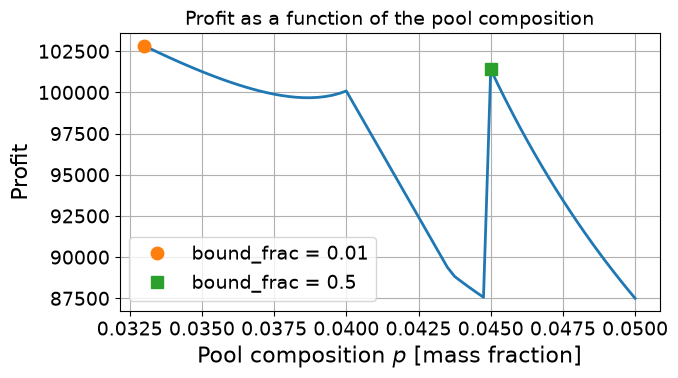

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_grid, profit_grid, lw=2)
ax.plot(pyo.value(m_a.p), pyo.value(m_a.profit), "o", ms=9, label="bound_frac = 0.01")
ax.plot(pyo.value(m_b.p), pyo.value(m_b.profit), "s", ms=9, label="bound_frac = 0.5")
ax.set_xlabel("Pool composition $p$ [mass fraction]")
ax.set_ylabel("Profit")
ax.set_title("Profit as a function of the pool composition")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

## Comparing the three options


In [13]:
summary = pd.DataFrame(
    [
        ["1. Local farms only", "LP", profit_1, "leaves money on the table"],
        ["2. All farms, one truck each", "LP", profit_2, "needs a second truck"],
        ["3. Remote farms pooled", "bilinear NLP", pyo.value(m_a.profit), "nonconvex"],
    ],
    columns=["Option", "Model class", "Profit", "Catch"],
)
display(summary.round(2))

,Option,Model class,Profit,Catch
0,1. Local farms only,LP,81000.00,leaves money on the table
1,"2. All farms, one truck each",LP,122441.18,needs a second truck
2,3. Remote farms pooled,bilinear NLP,102833.33,nonconvex


## Take away messages

* Pooling recovers most of the value of the remote farms without a second truck. But the model that says so is **nonconvex**, and the number it reports depends on where the solver started.
* A **bilinear** term --- a product of two decision variables --- is smooth but irreducibly nonconvex. Unlike $|x|$, it cannot be reformulated away.
* Report the initial point, or the option that determined it. A result you cannot reproduce is a result you cannot defend.
* What *can* be done is to **relax** the bilinear term: replace it by a new variable bounded by linear functions of its factors. That gives a true upper bound on the profit, and tightening such bounds until they meet the optimum is what the global optimization lecture does.
